# Predictive Analysis- Data Preprocessing (REGRESSION)
This notebook preprocesses our dataset and merges the 5 individual datasets into a master dataset, with target variables for Remaining Useful Life (RUL) prediction (regression).


In [1]:
%pip install pandas numpy matplotlib seaborn



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta


### Loading all datasets


In [3]:
DATA_PATH = "../data/raw/"

telemetry_df = pd.read_csv(f'{DATA_PATH}PdM_telemetry.csv', parse_dates=['datetime'])
errors_df = pd.read_csv(f'{DATA_PATH}PdM_errors.csv', parse_dates=['datetime'])
maintenance_df = pd.read_csv(f'{DATA_PATH}PdM_maint.csv', parse_dates=['datetime'])
failures_df = pd.read_csv(f'{DATA_PATH}PdM_failures.csv', parse_dates=['datetime'])
machines_df = pd.read_csv(f'{DATA_PATH}PdM_machines.csv')

print(f"Telemetry: {len(telemetry_df):,} rows")
print(f"Errors: {len(errors_df):,} rows")
print(f"Maintenance: {len(maintenance_df):,} rows")
print(f"Failures: {len(failures_df):,} rows")
print(f"Machines: {len(machines_df):,} rows")


Telemetry: 876,100 rows
Errors: 3,919 rows
Maintenance: 3,286 rows
Failures: 761 rows
Machines: 100 rows


### Data filtering
Our dataset has maintainance data from 2014 but other data (like failure, telementry) starts from 2015. So, we need to filter our maintainace data to match other dataset and start from 2015.


In [4]:
print(f"Before: {len(maintenance_df):,} rows")
print(f"Date range: {maintenance_df['datetime'].min()} to {maintenance_df['datetime'].max()}")

maintenance_df = maintenance_df[maintenance_df['datetime'] >= '2015-01-01']

print(f"After: {len(maintenance_df):,} rows")
print(f"Date range: {maintenance_df['datetime'].min()} to {maintenance_df['datetime'].max()}")


Before: 3,286 rows
Date range: 2014-06-01 06:00:00 to 2016-01-01 06:00:00
After: 2,886 rows
Date range: 2015-01-01 06:00:00 to 2016-01-01 06:00:00


### Preparing events data

In this part, we are processing events data (errors, maintenance, failures) for each machine at every hour, and creating 3 pivot tables where each row represents the event status of a specific machine at a specific time. These tables include binary flags for each event type showing whether any event occurred during that time.
<br>This structure makes it easier to analyze a machine's condition over time: "when & what event happened to this machine?" and will be merged into master dataset later.


In [5]:
# Processing ERROR events
errors_pivot = errors_df.pivot_table(
    index=['machineID', 'datetime'],
    columns='errorID',
    aggfunc='size',
    fill_value=0
).reset_index()

errors_pivot.columns = ['machineID', 'datetime'] + [f'{col}' for col in errors_pivot.columns[2:]]
errors_pivot['has_error'] = (errors_pivot.iloc[:, 2:].sum(axis=1) > 0).astype(int)

print(f"Error pivot columns: {list(errors_pivot.columns)}")


Error pivot columns: ['machineID', 'datetime', 'error1', 'error2', 'error3', 'error4', 'error5', 'has_error']


In [6]:
# Processing MAINTENANCE events
maintenance_pivot = maintenance_df.pivot_table(
    index=['machineID', 'datetime'],
    columns='comp',
    aggfunc='size',
    fill_value=0
).reset_index()

maintenance_pivot.columns = ['machineID', 'datetime'] + [f'maint_{col}' for col in maintenance_pivot.columns[2:]]
maintenance_pivot['has_maintenance'] = (maintenance_pivot.iloc[:, 2:].sum(axis=1) > 0).astype(int)

print(f"Maintenance columns: {list(maintenance_pivot.columns)}")


Maintenance columns: ['machineID', 'datetime', 'maint_comp1', 'maint_comp2', 'maint_comp3', 'maint_comp4', 'has_maintenance']


In [7]:
# Processing FAILURE events
failures_pivot = failures_df.pivot_table(
    index=['machineID', 'datetime'],
    columns='failure',
    aggfunc='size',
    fill_value=0
).reset_index()

failures_pivot.columns = ['machineID', 'datetime'] + [f'failure_{col}' for col in failures_pivot.columns[2:]]
failures_pivot['has_failure'] = (failures_pivot.iloc[:, 2:].sum(axis=1) > 0).astype(int)

print(f"Failure columns: {list(failures_pivot.columns)}")


Failure columns: ['machineID', 'datetime', 'failure_comp1', 'failure_comp2', 'failure_comp3', 'failure_comp4', 'has_failure']


### Merging dataset

Here, we are merging all our datasets into one master dataset. <br>
We take the telementry dataset as the base table by making a copy of it first, then do a left join on each of our pivoted events table one by one on the columns of machineID and datetime. Any row with a missing event data will be assinged a 'NaN' value on merge so we replace the NaN values with 0, representing the event as false for that entry.


In [8]:
# making a copy of telemetry data as the base
master_df = telemetry_df.copy()

# merging with machines dataset (no datetime on this)
master_df = master_df.merge(machines_df, on='machineID', how='left')

# merging with errors pivot dataset, replacing all NaN values with 0
master_df = master_df.merge(errors_pivot, on=['machineID', 'datetime'], how='left')
error_cols = [col for col in master_df.columns if col.startswith('error') or col == 'has_error']
master_df[error_cols] = master_df[error_cols].fillna(0).astype(int)

# merging with maintenance pivot dataset, replacing all NaN values with 0
master_df = master_df.merge(maintenance_pivot, on=['machineID', 'datetime'], how='left')
maint_cols = [col for col in master_df.columns if col.startswith('maint_') or col == 'has_maintenance']
master_df[maint_cols] = master_df[maint_cols].fillna(0).astype(int)

# mergeing with failures pivot dataset, replacing all NaN values with 0
master_df = master_df.merge(failures_pivot, on=['machineID', 'datetime'], how='left')
failure_cols = [col for col in master_df.columns if col.startswith('failure_') or col == 'has_failure']
master_df[failure_cols] = master_df[failure_cols].fillna(0).astype(int)

master_df = master_df.sort_values(['machineID', 'datetime']).reset_index(drop=True)

print(f"Merged dataset: {len(master_df):,} rows, {master_df.shape[1]} columns")


Merged dataset: 876,100 rows, 24 columns


### Creating RUL (Remaining Useful Life) Target Variable

For regression analysis, we calculate the Remaining Useful Life (RUL) - the time in hours until the next failure for each machine and component. If no failure occurs, we set RUL to a maximum value.


In [10]:
def create_rul_target(df, max_rul=720):
    """
    Creates Remaining Useful Life (RUL) target for failure prediction.
    
    For each row, calculates the time in hours until the next failure.
    Creates both general RUL and component-specific RUL targets.
    
    Parameters:
    - df: DataFrame with merged data
    - max_rul: Maximum RUL value to assign when no failure occurs (default: 720 hours = 30 days)
    
    Returns:
    - DataFrame with RUL columns added
    """
    df_copy = df.copy()
    
    # Initialize RUL columns with max value
    df_copy['RUL'] = max_rul
    df_copy['RUL_comp1'] = max_rul
    df_copy['RUL_comp2'] = max_rul
    df_copy['RUL_comp3'] = max_rul
    df_copy['RUL_comp4'] = max_rul
    
    # Process each machine separately
    machines = df_copy['machineID'].unique()
    
    print(f"Computing RUL for {len(machines)} machines...")
    
    for i, machine_id in enumerate(machines):
        if (i + 1) % 20 == 0:
            print(f"  Processed {i + 1}/{len(machines)} machines")
        
        # Get data for this machine
        machine_mask = df_copy['machineID'] == machine_id
        machine_data = df_copy[machine_mask].copy()
        
        # Get failure times for this machine
        failure_rows = machine_data[machine_data['has_failure'] == 1]
        
        if len(failure_rows) == 0:
            continue
        
        # For each timestamp in the machine's data
        for idx in machine_data.index:
            current_time = machine_data.loc[idx, 'datetime']
            
            # Find next failure (any component)
            future_failures = failure_rows[failure_rows['datetime'] > current_time]
            
            if len(future_failures) > 0:
                next_failure_time = future_failures['datetime'].iloc[0]
                rul_hours = (next_failure_time - current_time).total_seconds() / 3600
                df_copy.loc[idx, 'RUL'] = min(rul_hours, max_rul)
            
            # Calculate component-specific RUL
            for comp in [1, 2, 3, 4]:
                comp_failures = failure_rows[failure_rows[f'failure_comp{comp}'] == 1]
                future_comp_failures = comp_failures[comp_failures['datetime'] > current_time]
                
                if len(future_comp_failures) > 0:
                    next_comp_failure_time = future_comp_failures['datetime'].iloc[0]
                    comp_rul_hours = (next_comp_failure_time - current_time).total_seconds() / 3600
                    df_copy.loc[idx, f'RUL_comp{comp}'] = min(comp_rul_hours, max_rul)
    
    print(f"  Completed all {len(machines)} machines")
    return df_copy


In [11]:
print("Creating RUL targets... This may take a few minutes.")
master_df = create_rul_target(master_df, max_rul=720)
print("\nMaster dataframe updated with RUL (Remaining Useful Life) target variables.")


Creating RUL targets... This may take a few minutes.
Computing RUL for 100 machines...
  Processed 20/100 machines
  Processed 40/100 machines
  Processed 60/100 machines
  Processed 80/100 machines
  Processed 100/100 machines
  Completed all 100 machines

Master dataframe updated with RUL (Remaining Useful Life) target variables.


In [12]:
# Display RUL statistics
print("\nRUL Statistics:")
print(master_df[['RUL', 'RUL_comp1', 'RUL_comp2', 'RUL_comp3', 'RUL_comp4']].describe())



RUL Statistics:
                 RUL      RUL_comp1      RUL_comp2      RUL_comp3  \
count  876100.000000  876100.000000  876100.000000  876100.000000   
mean      531.078618     667.214872     646.943021     683.066521   
std       242.408904     150.727263     173.432100     128.397580   
min         1.000000       1.000000       1.000000       1.000000   
25%       318.000000     720.000000     720.000000     720.000000   
50%       720.000000     720.000000     720.000000     720.000000   
75%       720.000000     720.000000     720.000000     720.000000   
max       720.000000     720.000000     720.000000     720.000000   

           RUL_comp4  
count  876100.000000  
mean      669.463909  
std       148.008121  
min         1.000000  
25%       720.000000  
50%       720.000000  
75%       720.000000  
max       720.000000  


### Visualizing RUL Distribution


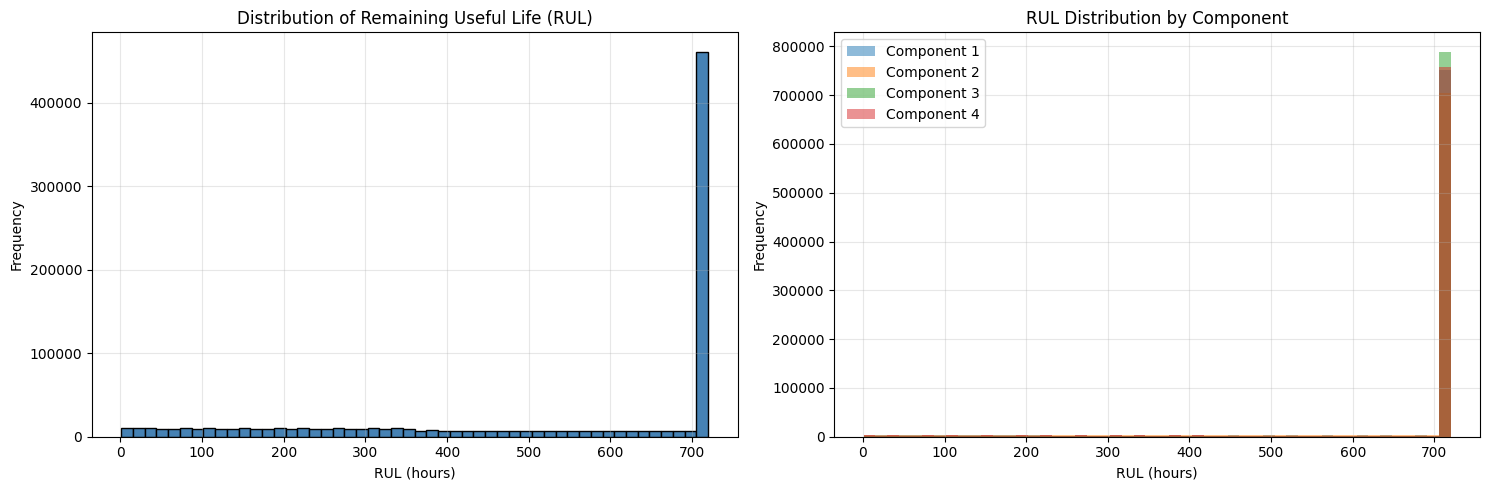

In [13]:
# Plot RUL distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# General RUL distribution
axes[0].hist(master_df['RUL'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_xlabel('RUL (hours)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Remaining Useful Life (RUL)')
axes[0].grid(True, alpha=0.3)

# Component-specific RUL
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, comp in enumerate([1, 2, 3, 4]):
    axes[1].hist(master_df[f'RUL_comp{comp}'], bins=50, alpha=0.5, 
                 label=f'Component {comp}', color=colors[i])
axes[1].set_xlabel('RUL (hours)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('RUL Distribution by Component')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Storing the master regression dataset with metadata

Here, we save our master dataset as csv to be used for regression modeling and we also save its column metadata for easier context & schema access


In [14]:
import os
OUTPUT_PATH = "../data/processed/regression/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

output_file = f'{OUTPUT_PATH}master_dataset_rul.csv'
master_df.to_csv(output_file, index=False)
print(f"Saved regression dataset to: {output_file}")


Saved regression dataset to: ../data/processed/regression/master_dataset_rul.csv


In [15]:
# save column metadata
import json

column_info = {
    'total_columns': master_df.shape[1],
    'identifier_columns': ['machineID', 'datetime'],
    'sensor_columns': ['volt', 'rotate', 'pressure', 'vibration'],
    'machine_columns': ['model', 'age'],
    'error_columns': [col for col in master_df.columns if col.startswith('error')],
    'maintenance_columns': [col for col in master_df.columns if col.startswith('maint_')],
    'failure_columns': [col for col in master_df.columns if col.startswith('failure_')],
    'target_columns': [col for col in master_df.columns if col.startswith('RUL')],
    'target_type': 'regression',
    'max_rul_hours': 720
}

metadata_file = f'{OUTPUT_PATH}regression_preprocessing_metadata.json'
with open(metadata_file, 'w') as f:
    json.dump(column_info, f, indent=2)
    
print(f"Saved metadata to: {metadata_file}")


Saved metadata to: ../data/processed/regression/regression_preprocessing_metadata.json


### Summary of the regression dataset


In [16]:
# Calculate summary statistics
rul_stats = master_df['RUL'].describe()

summary_stats = {
    'Metric': [
        'Total Rows',
        'Total Columns',
        'Date Range',
        'Number of Machines',
        'Target Type',
        'Mean RUL (hours)',
        'Median RUL (hours)',
        'Min RUL (hours)',
        'Max RUL (hours)',
        'Machines with Failures',
        'Total Error Events',
        'Total Maintenance Events',
        'Total Failure Events'
    ],
    'Value': [
        f"{len(master_df):,}",
        master_df.shape[1],
        f"{master_df['datetime'].min().date()} to {master_df['datetime'].max().date()}",
        master_df['machineID'].nunique(),
        "RUL (Remaining Useful Life)",
        f"{rul_stats['mean']:.2f}",
        f"{rul_stats['50%']:.2f}",
        f"{rul_stats['min']:.2f}",
        f"{rul_stats['max']:.2f}",
        f"{master_df[master_df['has_failure'] == 1]['machineID'].nunique()}/{master_df['machineID'].nunique()}",
        f"{master_df['has_error'].sum():,}",
        f"{master_df['has_maintenance'].sum():,}",
        f"{master_df['has_failure'].sum():,}"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print("\n")
print(summary_df.to_string(index=False))




                  Metric                       Value
              Total Rows                     876,100
           Total Columns                          29
              Date Range    2015-01-01 to 2016-01-01
      Number of Machines                         100
             Target Type RUL (Remaining Useful Life)
        Mean RUL (hours)                      531.08
      Median RUL (hours)                      720.00
         Min RUL (hours)                        1.00
         Max RUL (hours)                      720.00
  Machines with Failures                      98/100
      Total Error Events                       3,616
Total Maintenance Events                       2,163
    Total Failure Events                         719


### Regression Dataset Complete!

This notebook has successfully created a regression dataset with RUL (Remaining Useful Life) targets. The dataset is ready for feature engineering and model training.
